# Librerias

In [3]:
import pandas as pd
import tensorflow as tf
%matplotlib inline
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf
import numpy as np
import keras
import seaborn as sns
from keras import layers
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, chi2 as chi2_dist
#from ydata_profiling import ProfileReport


print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("Built with CUDA:", tf.test.is_built_with_cuda())

Num GPUs Available:  0
Built with CUDA: True


2026-05-10 20:53:09.592806: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:981] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2026-05-10 20:53:09.593962: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory
2026-05-10 20:53:09.594025: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublas.so.11'; dlerror: libcublas.so.11: cannot open shared object file: No such file or directory
2026-05-10 20:53:09.594068: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcublasLt.so.11'; dlerror: libcublasLt.so.11: cannot open shared object file: No such file or directory
2026-05-10 20:53:09.594107: W tensorflow/c

# Analisis exploratorio de los datos

In [4]:
df = pd.read_csv('Datos/santiago_final_con_metro.csv')
df = df.dropna(subset=['price'])
df = df.drop(['id'], axis = 1)

train_df = df.sample(frac=0.8, random_state=42)
test_df = df.drop(train_df.index)


train_df = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

test_df = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_df,
    task = tfdf.keras.Task.REGRESSION,
    label = 'price',
)

train_df = train_df.prefetch(tf.data.AUTOTUNE)

2026-05-10 20:53:14.578616: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 178842 entries, 0 to 189690
Data columns (total 13 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   neighbourhood             178842 non-null  object 
 1   latitude                  178842 non-null  float64
 2   longitude                 178842 non-null  float64
 3   room_type                 178842 non-null  object 
 4   price                     178842 non-null  float64
 5   minimum_nights            178842 non-null  int64  
 6   number_of_reviews         178842 non-null  int64  
 7   availability_365          178842 non-null  int64  
 8   number_of_reviews_ltm     178842 non-null  int64  
 9   archivo_fecha_origen      178842 non-null  object 
 10  Dólar                     178842 non-null  int64  
 11  nombre_estacion           178842 non-null  object 
 12  fecha_inauguracion_metro  173854 non-null  object 
dtypes: float64(3), int64(5), object(5)
memory usage: 

In [6]:
stats_df = df.describe(include='object').T
print("Estadísticas descriptivas:")
display(stats_df)

print("\nObservaciones duplicadas:", df.duplicated().sum())
print("Valores nulos por columna:")
print(df.isnull().sum())


Estadísticas descriptivas:


,count,unique,top,freq
neighbourhood,178842,30,Santiago,64033
room_type,178842,4,Entire home/apt,140764
archivo_fecha_origen,178842,19,2025-08-29,13234
nombre_estacion,178842,121,Los Dominicos,15239
fecha_inauguracion_metro,173854,24,1980-08-31,35814



Observaciones duplicadas: 47
Valores nulos por columna:
neighbourhood                  0
latitude                       0
longitude                      0
room_type                      0
price                          0
minimum_nights                 0
number_of_reviews              0
availability_365               0
number_of_reviews_ltm          0
archivo_fecha_origen           0
Dólar                          0
nombre_estacion                0
fecha_inauguracion_metro    4988
dtype: int64


## Histogramas

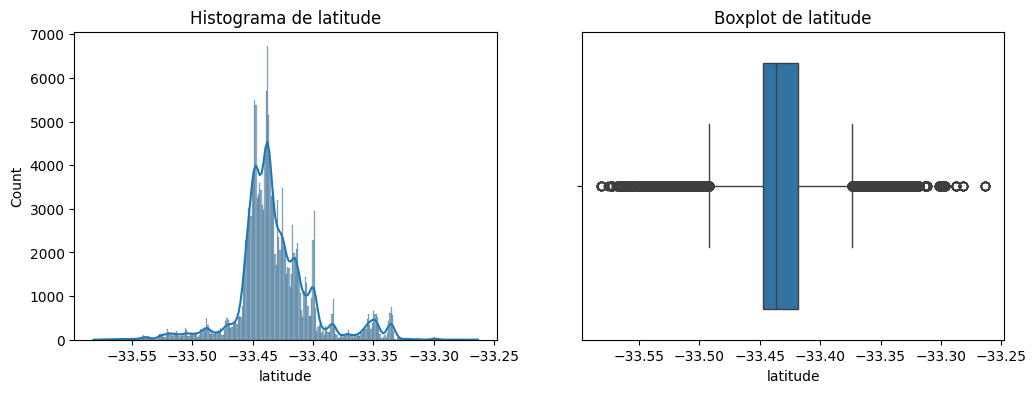

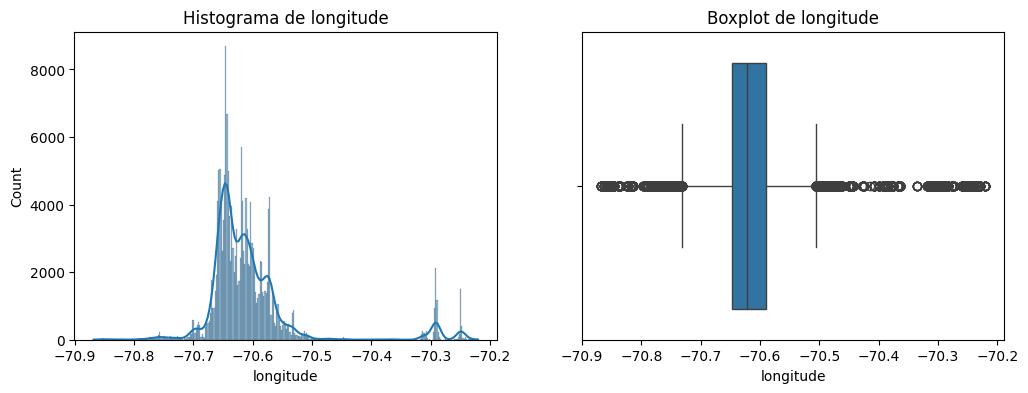

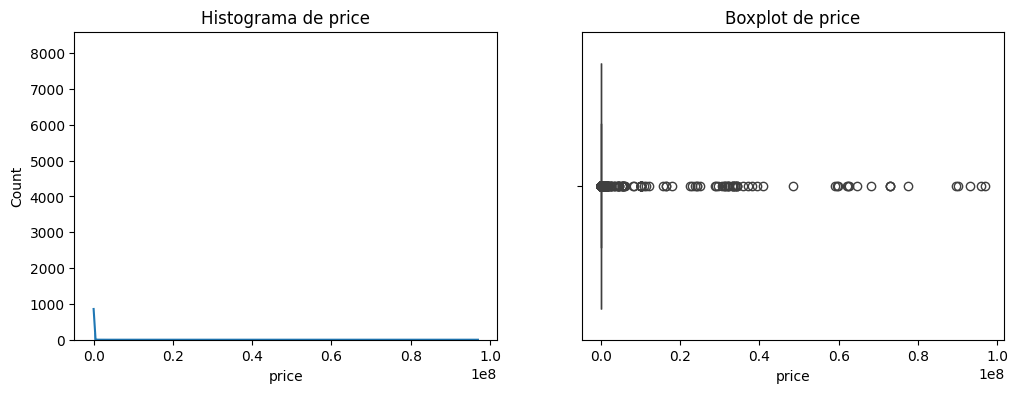

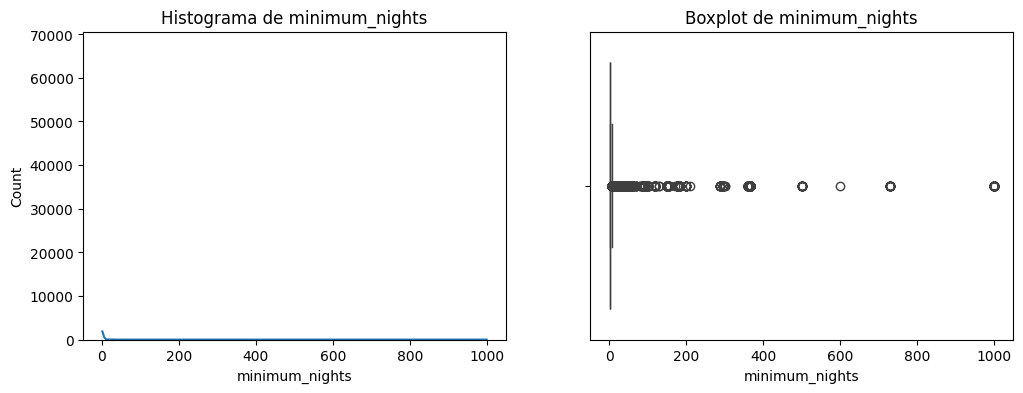

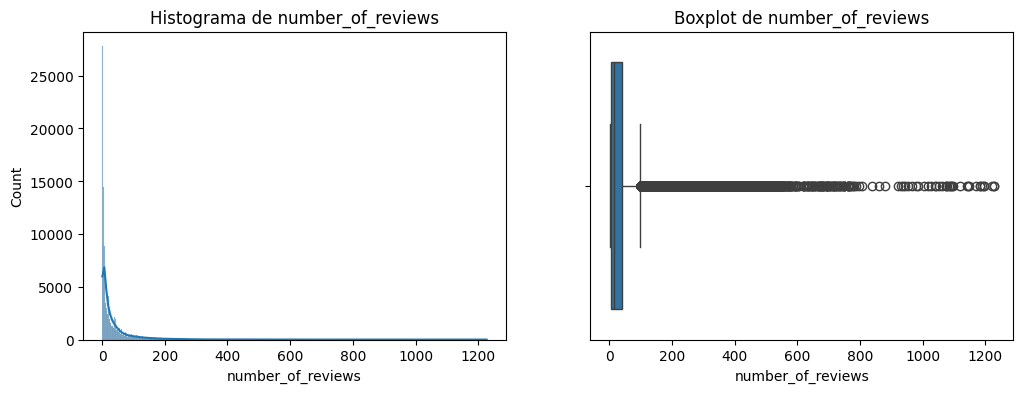

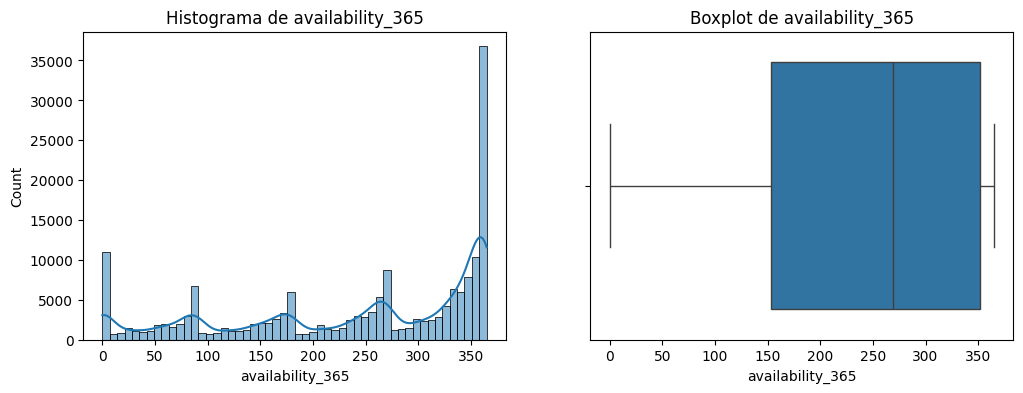

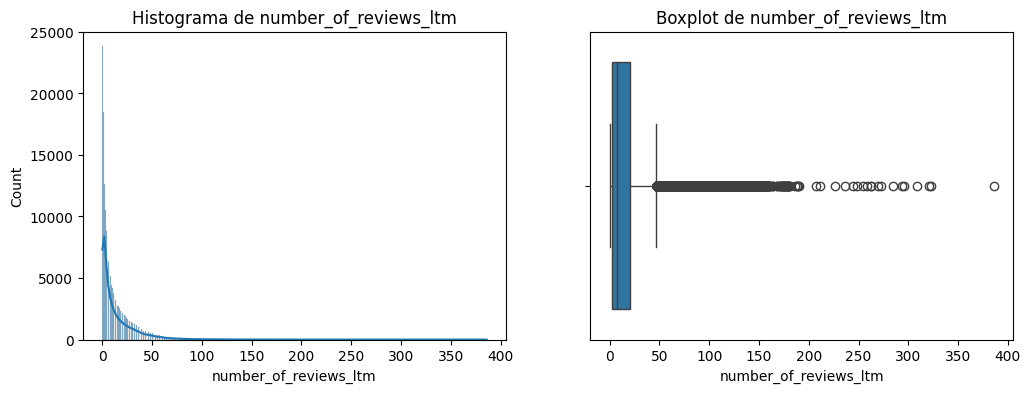

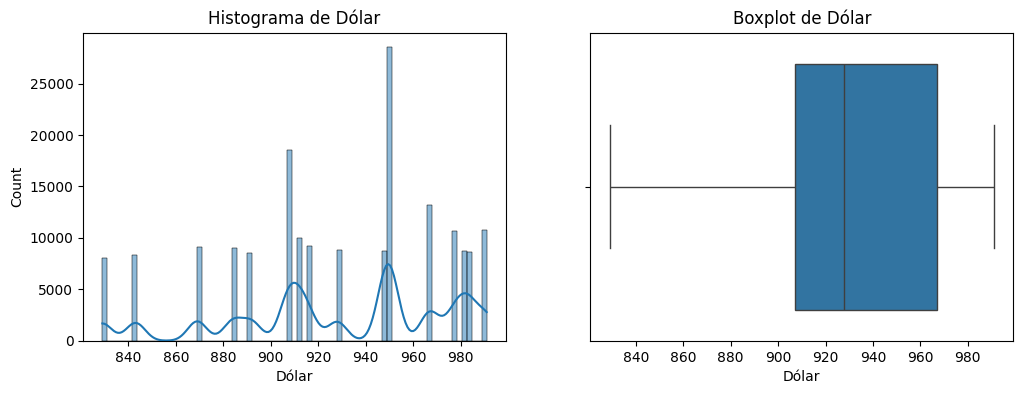

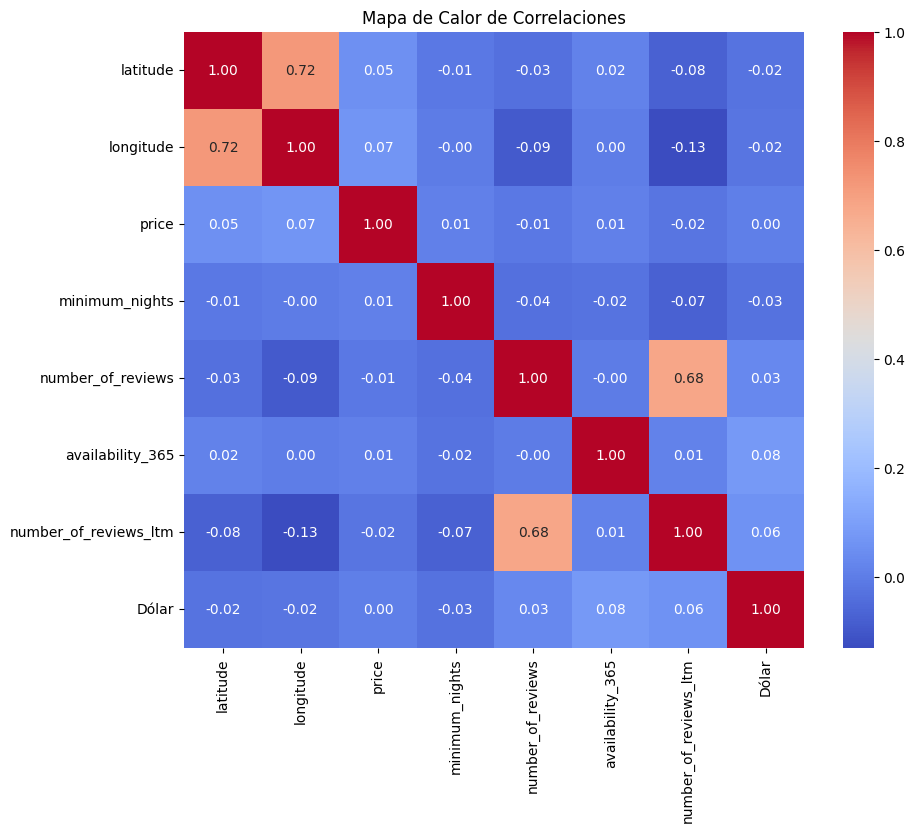

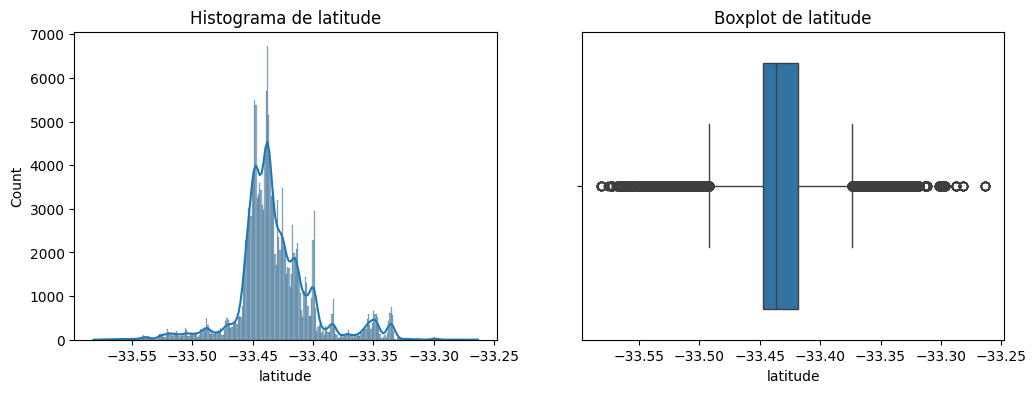

latitude - skewness> 0.52
latitude - Kurtosis> 2.74
------------------------------


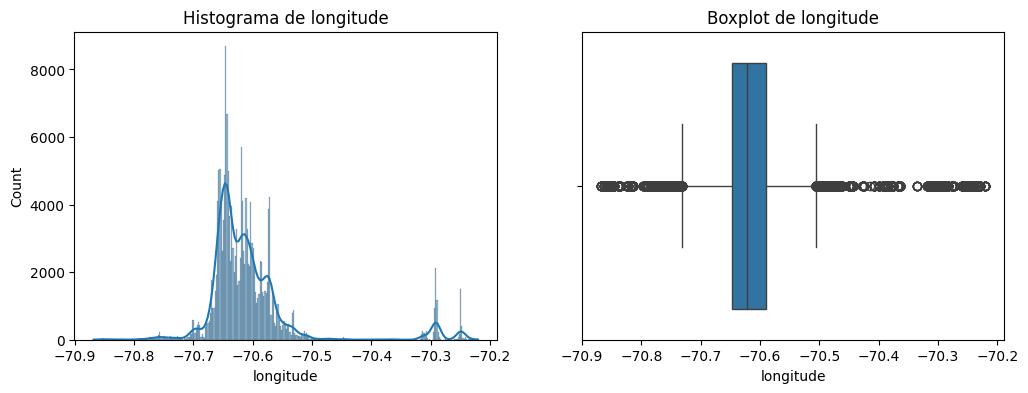

longitude - skewness> 2.76
longitude - Kurtosis> 8.86
------------------------------


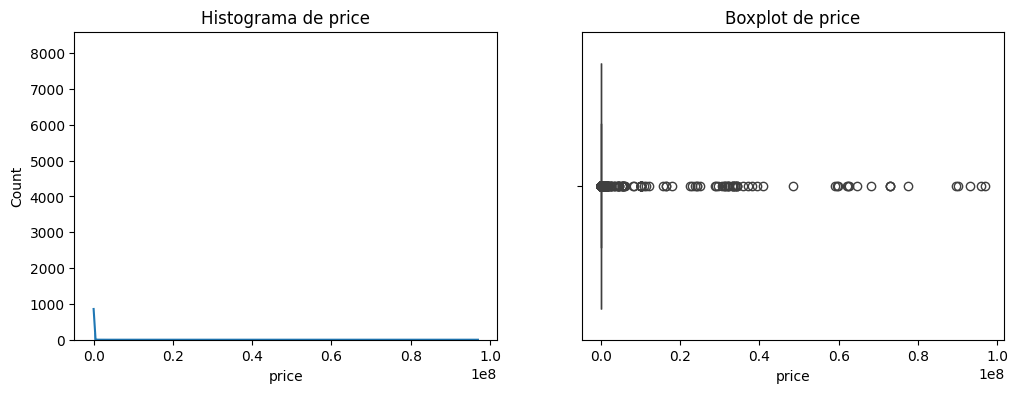

price - skewness> 74.59
price - Kurtosis> 6407.88
------------------------------


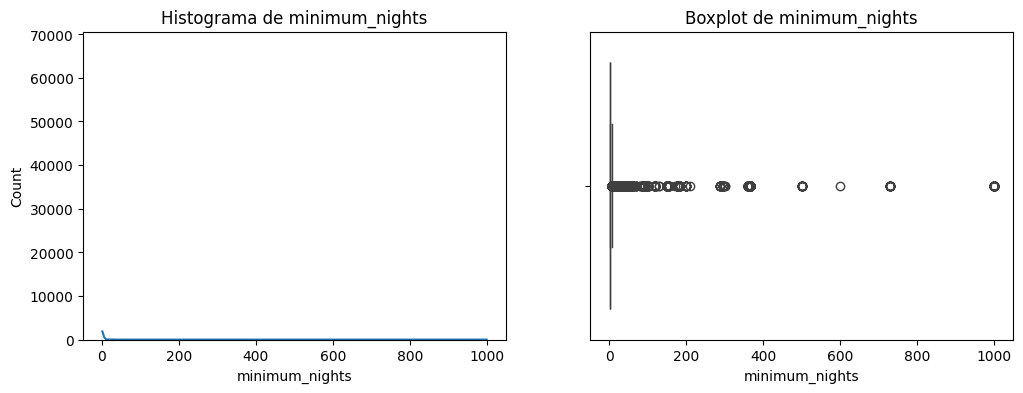

minimum_nights - skewness> 26.47
minimum_nights - Kurtosis> 920.26
------------------------------


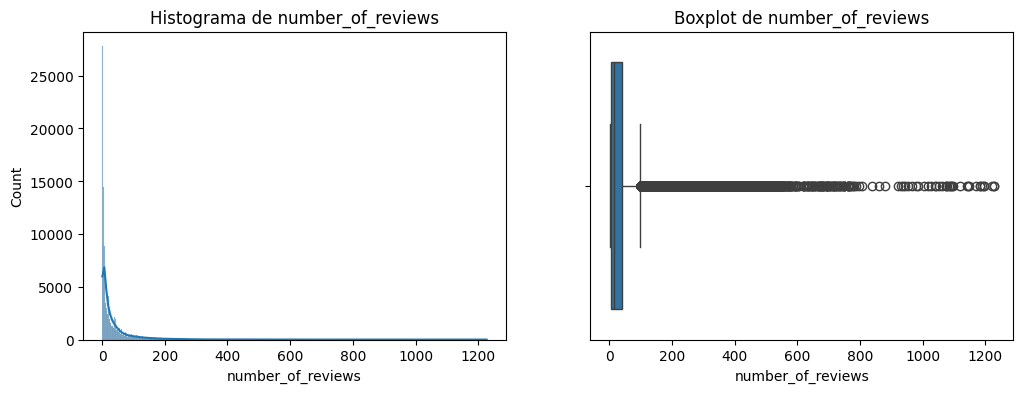

number_of_reviews - skewness> 4.37
number_of_reviews - Kurtosis> 35.02
------------------------------


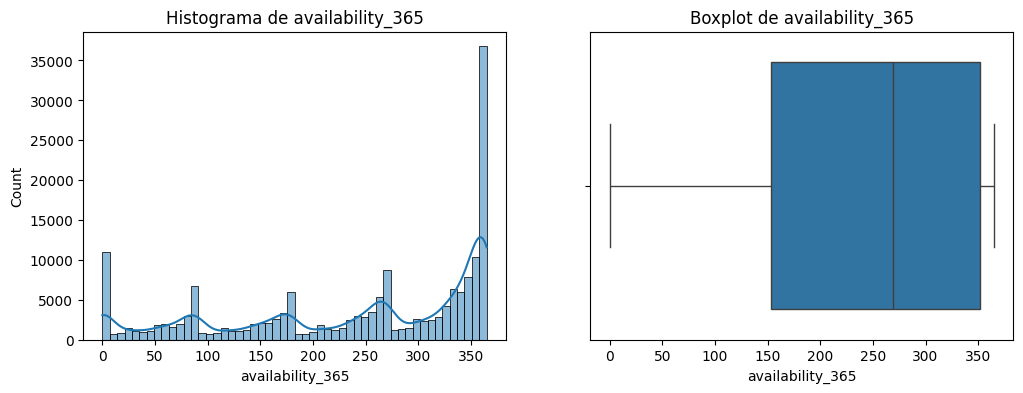

availability_365 - skewness> -0.67
availability_365 - Kurtosis> -0.90
------------------------------


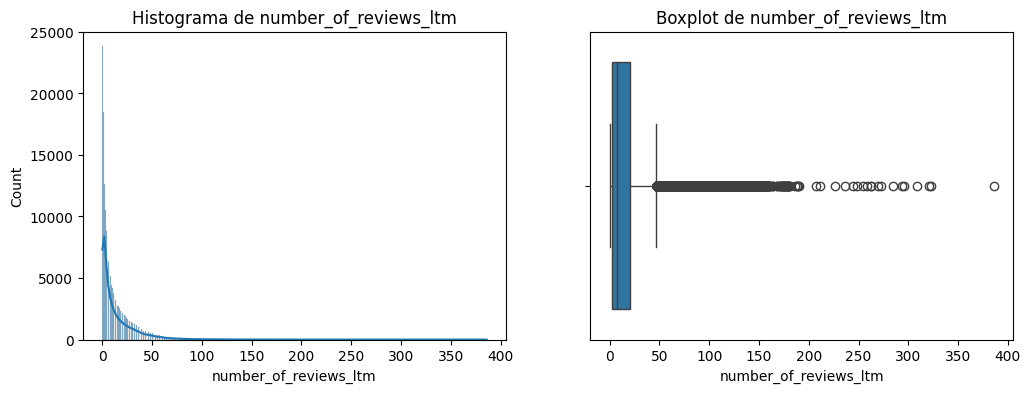

number_of_reviews_ltm - skewness> 2.72
number_of_reviews_ltm - Kurtosis> 12.75
------------------------------


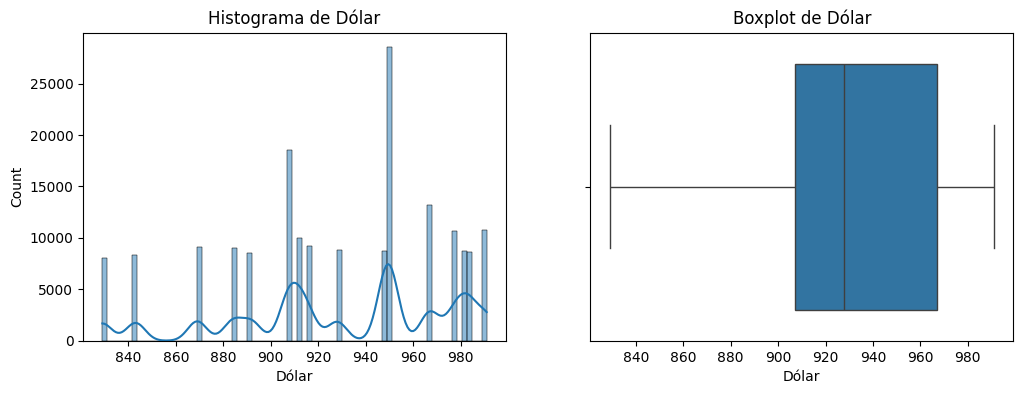

Dólar - skewness> -0.52
Dólar - Kurtosis> -0.62
------------------------------


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Boxplot de {col}')
    
    plt.show()
    print(f'{col} - skewness> {df[col].skew():.2f}')
    print(f'{col} - Kurtosis> {df[col].kurt():.2f}')
    print('-'*30)

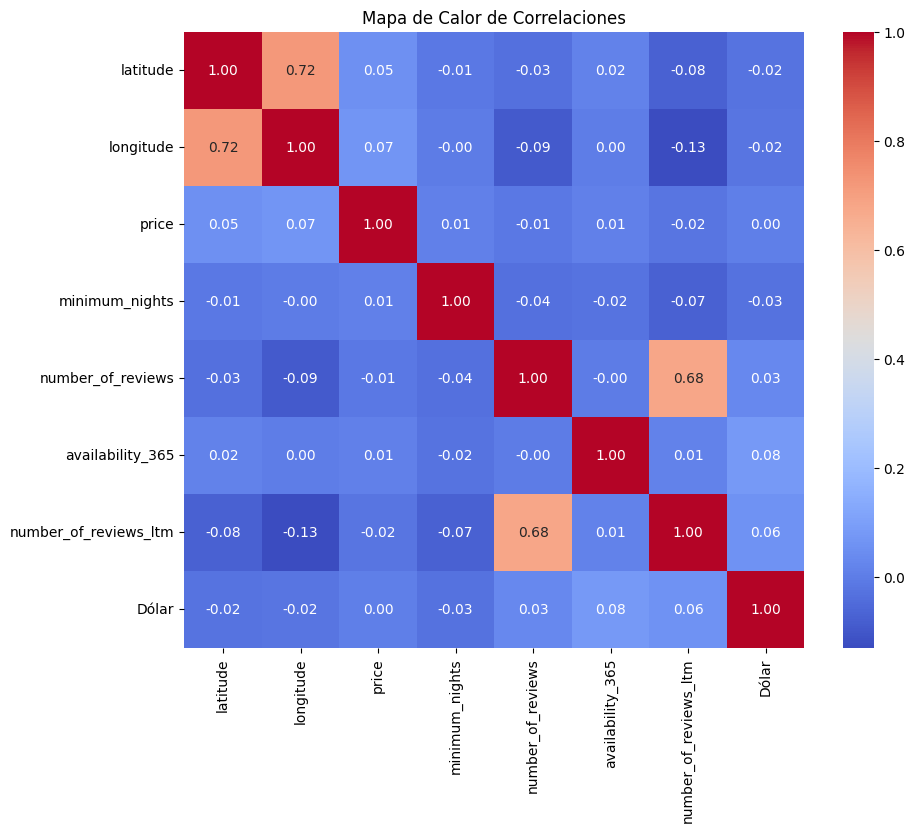

In [11]:
plt.figure(figsize=(10,8))
correlation_matrix = df.select_dtypes(include=(np.number)).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Mapa de Calor de Correlaciones")
plt.show()

In [12]:
categorical_columns = df.select_dtypes(include=['object']).columns
results = []
alpha = 0.5

for i in range(len(categorical_columns)):
    for j in range(i + 1, len(categorical_columns)):
        col1 = categorical_columns[i]
        col2 = categorical_columns[j]
        contingency_table = pd.crosstab(df[col1], df[col2])
        chi2_stat, p, dof, expected = chi2_contingency(contingency_table)
        chi2_crit = chi2_dist.ppf(1 - alpha, dof)
        results.append((col1, col2, chi2_stat, chi2_crit, p))
        
chi_results_df = pd.DataFrame(
    results,
    columns=['Variable 1', 'Variable 2', 'Xi-cuadrado', 'Valor crítico', 'p-value']
)
print("Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):")
display(chi_results_df)

Resultados de Ji-cuadrado (p-value < 0.05 indica relación significativa):


,Variable 1,Variable 2,Xi-cuadrado,Valor crítico,p-value
0,neighbourhood,room_type,1.161882e+04,86.334249,0.000000e+00
1,neighbourhood,archivo_fecha_origen,7.685386e+02,521.333485,1.045607e-11
2,neighbourhood,nombre_estacion,3.279439e+06,3479.333356,0.000000e+00
3,neighbourhood,fecha_inauguracion_metro,1.439630e+06,666.333452,0.000000e+00
4,room_type,archivo_fecha_origen,9.570755e+02,53.334816,1.862494e-165
5,room_type,nombre_estacion,2.599684e+04,359.333553,0.000000e+00
6,room_type,fecha_inauguracion_metro,9.819314e+03,68.334491,0.000000e+00
7,archivo_fecha_origen,nombre_estacion,2.248023e+03,2159.333370,9.150157e-02
8,archivo_fecha_origen,fecha_inauguracion_metro,7.054594e+02,413.333525,1.633891e-17
9,nombre_estacion,fecha_inauguracion_metro,3.998642e+06,2621.333363,0.000000e+00


In [13]:
profile = ProfileReport(df, title="Student Exam Performance Dataset")
profile.to_file("StudentExamPerformance_EDA.html")
print("Reporte generado como 'StudentExamPerformance_EDA.html'")

Export report to file: 100%|██████████| 1/1 [00:00<00:00, 101.16it/s]

Reporte generado como 'StudentExamPerformance_EDA.html'


# Modelos

# Gradient Boost 
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/GradientBoostedTreesModel

In [5]:
model = tfdf.keras.GradientBoostedTreesModel(
    task = tfdf.keras.Task.REGRESSION,
    num_trees = 500,
    max_depth = 6,
    growing_strategy = "BEST_FIRST_GLOBAL",
    shrinkage = 0.1,
    l2_regularization = 0.1
)
model.fit(train_df)

Use /tmp/tmp4jlda9_j as temporary training directory


Reading training dataset...
Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Instructions for updating:
Lambda fuctions will be no more assumed to be used in the statement where they are used, or at least in the same block. https://github.com/tensorflow/tensorflow/issues/56089


Training dataset read in 0:00:03.370440. Found 143074 examples.
Training model...


2026-05-10 20:53:25.779992: W external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:1790] "goss_alpha" set but "sampling_method" not equal to "GOSS".
2026-05-10 20:53:25.780017: W external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:1800] "goss_beta" set but "sampling_method" not equal to "GOSS".
2026-05-10 20:53:25.780022: W external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:1814] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".
2026-05-10 20:53:25.781041: I external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:452] Default loss set to SQUARED_ERROR
2026-05-10 20:53:25.781060: I external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:1077] Training gradient boosted tree on 143074 example(s) and 12 feature(s).
2026-05-10 20:53:25.792445: 

Model trained in 0:00:04.849276
Compiling model...


2026-05-10 20:53:30.564243: I external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:1568] Create final snapshot of the model at iteration 77
2026-05-10 20:53:30.566446: I external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:247] Truncates the model to 48 tree(s) i.e. 48  iteration(s).
2026-05-10 20:53:30.566619: I external/ydf/yggdrasil_decision_forests/learner/gradient_boosted_trees/gradient_boosted_trees.cc:309] Final model num-trees:48 valid-loss:272913.843750 valid-rmse:272913.843750
[INFO 2026-05-10T20:53:30.581143381-04:00 kernel.cc:1214] Loading model from path /tmp/tmp4jlda9_j/model/ with prefix 00a33ac326d14b85
[INFO 2026-05-10T20:53:30.585419256-04:00 abstract_model.cc:1311] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 2026-05-10T20:53:30.58545568-04:00 kernel.cc:1046] Use fast generic engine


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: could not get source code
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Model compiled.


In [9]:
# Evaluar el modelo
resultados = model.evaluate(test_df, return_dict=True)
print("Métricas disponibles:", resultados.keys())

# 1. Tomar un lote de datos del set de prueba
for features, labels in test_df:
    # 2. Hacer la predicción
    preds = model.predict(features)
    
    # 3. Ver los primeros 5 resultados
    print("Primeras 5 Predicciones vs Realidad:")
    print(f"Predicho: ${preds} | Real: ${labels}")
    
    # 4. Calcular el RMSE manual de este lote
    rmse_manual = np.sqrt(np.mean((preds.flatten() - labels.numpy())**2))
    print(f"\nRMSE Manual del lote: ${rmse_manual:,.0f}")

36/36 [==============================] - 0s 4ms/step - loss: 0.0000e+00
Métricas disponibles: dict_keys(['loss'])
32/32 [==============================] - 0s 870us/step
Primeras 5 Predicciones vs Realidad:
Predicho: $[[ 3.08772734e+04]
 [ 4.33597461e+04]
 [ 2.90985410e+04]
 [ 6.48737812e+04]
 [ 3.76200664e+04]
 [ 3.18912910e+04]
 [ 4.77435117e+04]
 [ 6.82806484e+04]
 [ 6.95566953e+04]
 [ 7.10492969e+04]
 [ 2.53518125e+04]
 [ 3.44985742e+04]
 [ 2.89302988e+04]
 [ 2.35953062e+05]
 [ 2.53988457e+04]
 [ 8.46356797e+04]
 [ 6.49820459e+03]
 [ 2.79318457e+04]
 [ 1.41622979e+04]
 [ 3.75491562e+04]
 [ 5.63311797e+04]
 [ 2.76282207e+04]
 [ 2.75395344e+05]
 [ 2.91145703e+04]
 [ 2.66215527e+04]
 [ 6.01857109e+04]
 [ 2.80958711e+04]
 [ 4.21552344e+04]
 [ 2.54207461e+04]
 [ 2.53988457e+04]
 [ 5.87134453e+04]
 [ 1.51505312e+05]
 [ 4.12570156e+04]
 [ 3.45249297e+04]
 [ 3.36183828e+04]
 [ 2.01296582e+04]
 [ 3.67433711e+04]
 [ 3.98447188e+04]
 [ 2.87639938e+05]
 [ 1.49944250e+05]
 [ 4.48782422e+04]
 [ 4

# Random Forest Regressor
https://www.tensorflow.org/decision_forests/api_docs/python/tfdf/keras/RandomForestModel

In [10]:
model_rf = tfdf.keras.RandomForestModel(
    task = tfdf.keras.Task.REGRESSION,
    num_trees = 500, 
    max_depth = 16, 
    growing_strategy = "BEST_FIRST_GLOBAL",
)

model_rf.fit(train_df) 

Use /tmp/tmpdiek4ggm as temporary training directory
Reading training dataset...
Training dataset read in 0:00:00.699239. Found 143074 examples.
Training model...
Model trained in 0:00:04.387299
Compiling model...
Model compiled.


[INFO 2026-05-10T20:54:45.560179148-04:00 kernel.cc:1214] Loading model from path /tmp/tmpdiek4ggm/model/ with prefix 17667cce56c84f15
[INFO 2026-05-10T20:54:45.595559251-04:00 decision_forest.cc:661] Model loaded with 500 root(s), 30500 node(s), and 12 input feature(s).
[INFO 2026-05-10T20:54:45.595576977-04:00 abstract_model.cc:1311] Engine "RandomForestGeneric" built
[INFO 2026-05-10T20:54:45.595585132-04:00 kernel.cc:1046] Use fast generic engine


In [11]:
# 1. Listas para acumular absolutamente todo
todos_los_predichos = []
todos_los_reales = []

print(f"Calculando predicciones para las {len(test_df):,} filas del set de prueba...")

# 2. Recorrer el dataset completo (sin 'break')
for features, labels in test_df:
    # Predicción silenciosa del lote actual
    preds = model_rf.predict(features, verbose=0)
    
    # Guardar los valores en nuestras listas globales
    todos_los_predichos.extend(preds.flatten())
    todos_los_reales.extend(labels.numpy())

# 3. Convertir a arrays de Numpy para cálculos rápidos
todos_los_predichos = np.array(todos_los_predichos)
todos_los_reales = np.array(todos_los_reales)

# 4. Calcular métricas finales sobre el TOTAL
rmse_final = np.sqrt(np.mean((todos_los_predichos - todos_los_reales)**2))
mae_final = np.mean(np.abs(todos_los_predichos - todos_los_reales))

# 5. Mostrar resultados para tu Solemne
print("\n" + "="*40)
print("   RESULTADOS GLOBALES DEL MODELO")
print("="*40)
print(f"Total de datos evaluados: {len(todos_los_reales):,}")
print(f"RMSE Global: ${rmse_final:,.0f} pesos")
print(f"MAE Global:  ${mae_final:,.0f} pesos")
print("="*40)

Calculando predicciones para las 36 filas del set de prueba...

   RESULTADOS GLOBALES DEL MODELO
Total de datos evaluados: 35,768
RMSE Global: $802,391 pesos
MAE Global:  $44,367 pesos


# Deep Neural Network

In [12]:
y = df['price']
df = df.drop(['price'], axis=1)
x = df

# Separar los datos en train, validation, testing
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.01, random_state=42) #This return a data frame type
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.01, random_state=42)

# Crear Dataset para optimizar TF
train_ds = tf.data.Dataset.from_tensor_slices((x_train.values, y_train.values))
val_ds = tf.data.Dataset.from_tensor_slices((x_val.values, y_val.values))

# Optimizar Datasets
train_ds = train_ds.shuffle(buffer_size=10000).batch(32).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(32).prefetch(tf.data.AUTOTUNE)

ValueError: Failed to convert a NumPy array to a Tensor (Unsupported object type float).

In [13]:
input_columns = df.shape[1] - 1
model_mlp = keras.Sequential(
    [
        layers.Dense(30, activation="relu", input_shape=(input_columns), name="layer1"),
        layers.Dense(30, activation="relu", name="layer2"),
        layers.Dense(30, name="layer3"),
        layers.Dense(1)
    ]
)
x = tf.ones((1, 4))
y = model_mlp(x)
print("Number of weights after calling the model:", len(model_mlp.weights))  # 6
model_mlp.summary()

TypeError: 'int' object is not iterable

In [30]:
model_mlp.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae', tf.keras.metrics.RootMeanSquaredError()],
)

model_mlp.fit(
    train_ds,
    validation_data = val_ds,
    epochs=50,
    verbose = 1
)

NameError: name 'train_ds' is not defined